# Phase 3 — Association Rule Mining
**Owner:** Pattern Analyst &nbsp;|&nbsp; **Dataset:** PaySim Synthetic Financial Fraud &nbsp;|&nbsp; **Method:** Apriori (frequent itemsets + association rules)

## Goal of this phase
Surface **co-occurrence patterns** between transaction attributes that are *not* obvious from simple tabulation — expressed as `IF antecedent THEN consequent` rules and ranked by **Support, Confidence, and Lift**.

## Where this fits in the KDD pipeline
Phase 1 (Data Engineer) membangun pipeline preprocessing dengan dua cabang output. Cabang `select_pattern_features` menyiapkan **7 atribut perilaku yang sudah terdiskretisasi** dan menyimpannya sebagai `data_phase3_rules.parquet` — file itulah **satu-satunya sumber** untuk phase ini (*single source of truth*, tidak ada rekayasa fitur ulang di sisi Pattern Analyst):

| Attribute | Type | Values | Cara diskretisasi di Phase 1 |
|---|---|---|---|
| `type` | native categorical | PAYMENT, CASH_OUT, CASH_IN, TRANSFER, DEBIT | tidak perlu — sudah kategorikal |
| `amount_category` | binned | Low / Medium / High_Amount | `pd.qcut(amount, q=3)` — tertil equal-frequency |
| `time_segment` | binned | Midnight_to_Morning, Working_Hours, Evening | `pd.cut(step % 24, bins=[-1,6,18,24])` |
| `drain_category` | binned | Low_Drain / Mid_Drain / Full_Drain | `pd.cut(amount/oldbalanceOrg, [-0.01,0.25,0.90,1.01])` |
| `emptied_origin` | derived flag | Emptied / Not_Emptied | saldo pengirim menjadi 0 setelah transaksi |
| `orig_balance_consistency` | derived flag | Orig_Consistent / Orig_Mismatch | `abs(errorBalanceOrig) > 1` (dari nilai mentah) |
| `dest_kind` | derived flag | Dest_Merchant / Dest_Customer | `nameDest` diawali "M" |

> **Catatan kepatuhan:** notebook ini **100% label-free** — `isFraud` tidak pernah dimuat. Seleksi berbasis label diisolasi di notebook pendamping (`PA_anomaly_pattern_mining_and_validation.ipynb`).

**Deliverable of this notebook:** a ranked rule table (≥ 10 non-trivial, high-lift rules) with explicit business commentary.

## 0. Setup

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
print('Libraries loaded. pandas', pd.__version__)

Libraries loaded. pandas 3.0.2


## 1. Load the discretized pattern dataset (Phase 1 hand-off)
We search a few candidate locations so the notebook runs regardless of where the parquet lives on a teammate's machine.

In [30]:
candidates = [
    Path('../../data/processed/real_used/data_phase3_rules.parquet'),
    Path('../../data/processed/data_phase3_rules.parquet'),
    Path('../../../data_phase3_rules.parquet'),   # project-root copy
    Path('data_phase3_rules.parquet'),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'data_phase3_rules.parquet not found. Run the Phase 1 pattern_pipeline first, '
        'or place the file in one of: ' + ', '.join(str(c) for c in candidates))

df = pd.read_parquet(DATA_PATH)

# Kontrak hand-off Phase 1: 7 atribut perilaku terdiskretisasi (LABEL-FREE).
# Pattern Analyst memakai SEMUA atribut -> aturan lebih kaya, tanpa rekayasa fitur ulang.
PATTERN_COLS = ['type', 'amount_category', 'time_segment', 'drain_category',
                'emptied_origin', 'orig_balance_consistency', 'dest_kind']
missing = [c for c in PATTERN_COLS if c not in df.columns]
assert not missing, (f'Kontrak hand-off tidak terpenuhi, kolom hilang: {missing}. '
                     f'Jalankan ulang notebooks/Phase1/DE2_Preprocessing_Pipeline.ipynb.')

df = df[PATTERN_COLS].astype('object')
assert 'isFraud' not in df.columns, 'label bocor ke fitur!'
print(f'Loaded {len(df):,} transactions from: {DATA_PATH}')
print(f'Atribut perilaku ({len(PATTERN_COLS)}): {PATTERN_COLS}')
df.head()

Loaded 6,362,620 transactions from: ..\..\data\processed\real_used\data_phase3_rules.parquet
Atribut perilaku (7): ['type', 'amount_category', 'time_segment', 'drain_category', 'emptied_origin', 'orig_balance_consistency', 'dest_kind']


,type,amount_category,time_segment,drain_category,emptied_origin,orig_balance_consistency,dest_kind
0,PAYMENT,Low_Amount,Midnight_to_Morning,Low_Drain,Not_Emptied,Orig_Consistent,Dest_Merchant
1,PAYMENT,Low_Amount,Midnight_to_Morning,Low_Drain,Not_Emptied,Orig_Consistent,Dest_Merchant
2,TRANSFER,Low_Amount,Midnight_to_Morning,Full_Drain,Emptied,Orig_Consistent,Dest_Customer
3,CASH_OUT,Low_Amount,Midnight_to_Morning,Full_Drain,Emptied,Orig_Consistent,Dest_Customer
4,PAYMENT,Low_Amount,Midnight_to_Morning,Mid_Drain,Not_Emptied,Orig_Consistent,Dest_Merchant


## 2. Discretization review & univariate distributions
Before mining we confirm what each item *means* and how frequent it is. The single-item supports below become the baseline against which **Lift** is measured (lift = 1 means “no better than this baseline frequency”).

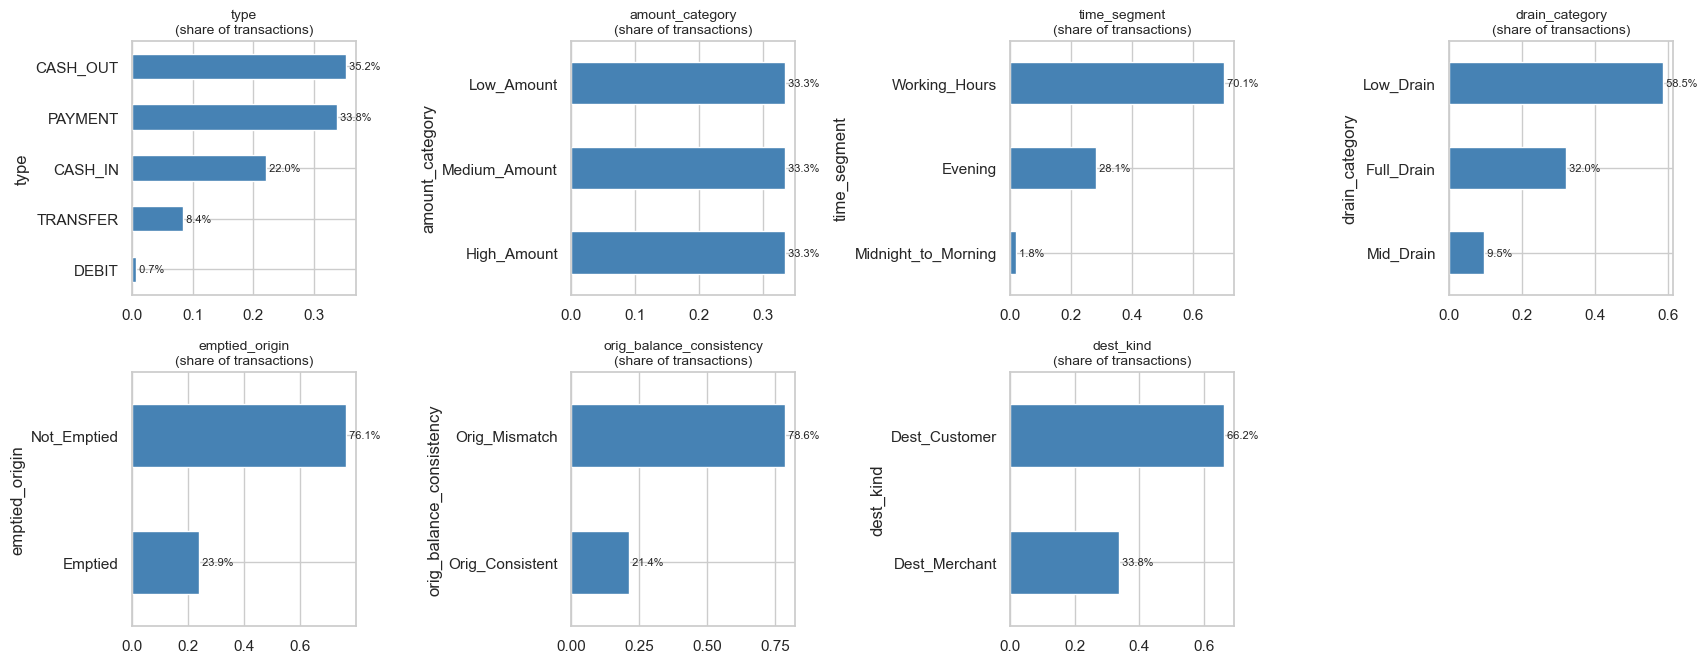

Note: amount_category is ~33/33/33 by design (equal-frequency qcut),
so any rule pointing to an amount bin with confidence >> 33% is genuinely informative.
Baseline tiap item di bawah menjadi pembanding untuk Lift.


In [31]:
import math

# Grid dinamis mengikuti jumlah atribut hand-off (kini 7, bukan lagi 3).
cols = list(df.columns)
ncols = 4
nrows = math.ceil(len(cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.4 * nrows))
axes = np.array(axes).flatten()

for ax, col in zip(axes, cols):
    vc = df[col].value_counts(normalize=True).sort_values()
    vc.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{col}\n(share of transactions)', fontsize=10)
    for i, v in enumerate(vc.values):
        ax.text(v, i, f' {v*100:.1f}%', va='center', fontsize=8)

for j in range(len(cols), len(axes)):   # sembunyikan panel sisa
    axes[j].set_visible(False)

plt.tight_layout(); plt.show()

print('Note: amount_category is ~33/33/33 by design (equal-frequency qcut),')
print('so any rule pointing to an amount bin with confidence >> 33% is genuinely informative.')
print('Baseline tiap item di bawah menjadi pembanding untuk Lift.')

## 3. Encode transactions as a one-hot boolean matrix
Apriori memperlakukan tiap baris sebagai *basket* berisi item. Tiap transaksi mengandung **tepat satu nilai dari masing-masing 7 atribut**, sehingga one-hot encoding menghasilkan basket berisi **20 item** (5 type + 3 amount + 3 time + 3 drain + 2 emptied + 2 consistency + 2 dest_kind).

Support tiap item tunggal di bawah = **baseline** yang menjadi pembanding **Lift** (lift = 1 berarti "tidak lebih baik dari frekuensi baseline ini").

In [32]:
basket = pd.get_dummies(df, prefix_sep='=').astype(bool)
print('Basket matrix:', basket.shape)
print('Items:', list(basket.columns))

item_support = basket.mean().sort_values(ascending=False)
print('\nSingle-item support (baseline frequencies):')
print((item_support * 100).round(2).astype(str) + ' %')

Basket matrix: (6362620, 20)
Items: ['type=CASH_IN', 'type=CASH_OUT', 'type=DEBIT', 'type=PAYMENT', 'type=TRANSFER', 'amount_category=High_Amount', 'amount_category=Low_Amount', 'amount_category=Medium_Amount', 'time_segment=Evening', 'time_segment=Midnight_to_Morning', 'time_segment=Working_Hours', 'drain_category=Full_Drain', 'drain_category=Low_Drain', 'drain_category=Mid_Drain', 'emptied_origin=Emptied', 'emptied_origin=Not_Emptied', 'orig_balance_consistency=Orig_Consistent', 'orig_balance_consistency=Orig_Mismatch', 'dest_kind=Dest_Customer', 'dest_kind=Dest_Merchant']

Single-item support (baseline frequencies):
orig_balance_consistency=Orig_Mismatch       78.6 %
emptied_origin=Not_Emptied                   76.1 %
time_segment=Working_Hours                  70.12 %
dest_kind=Dest_Customer                     66.19 %
drain_category=Low_Drain                    58.51 %
type=CASH_OUT                               35.17 %
type=PAYMENT                                33.81 %
dest_kind

## 3b. Redundancy check antar-atribut (justifikasi rule *non-trivial*)

Sebelum menambang, kita **kuantifikasi redundansi** antar atribut. Fitur kategorikal **tidak bisa** diukur dengan korelasi Pearson (itu untuk numerik), maka dipakai:

- **Cramér's V** — kekuatan asosiasi antar-**atribut** kategorikal (0 = independen, 1 = satu atribut menentukan yang lain **sempurna**).
- **phi** (korelasi one-hot 0/1) — menemukan pasangan **item** redundan yang memicu rule **tautologis** (lift tinggi, tapi 0 insight).

Tujuannya memenuhi syarat rubrik *"filter rules to retain only meaningful, **non-trivial** findings"* — kita harus tahu item mana yang redundan agar rule tautologisnya bisa disaring.

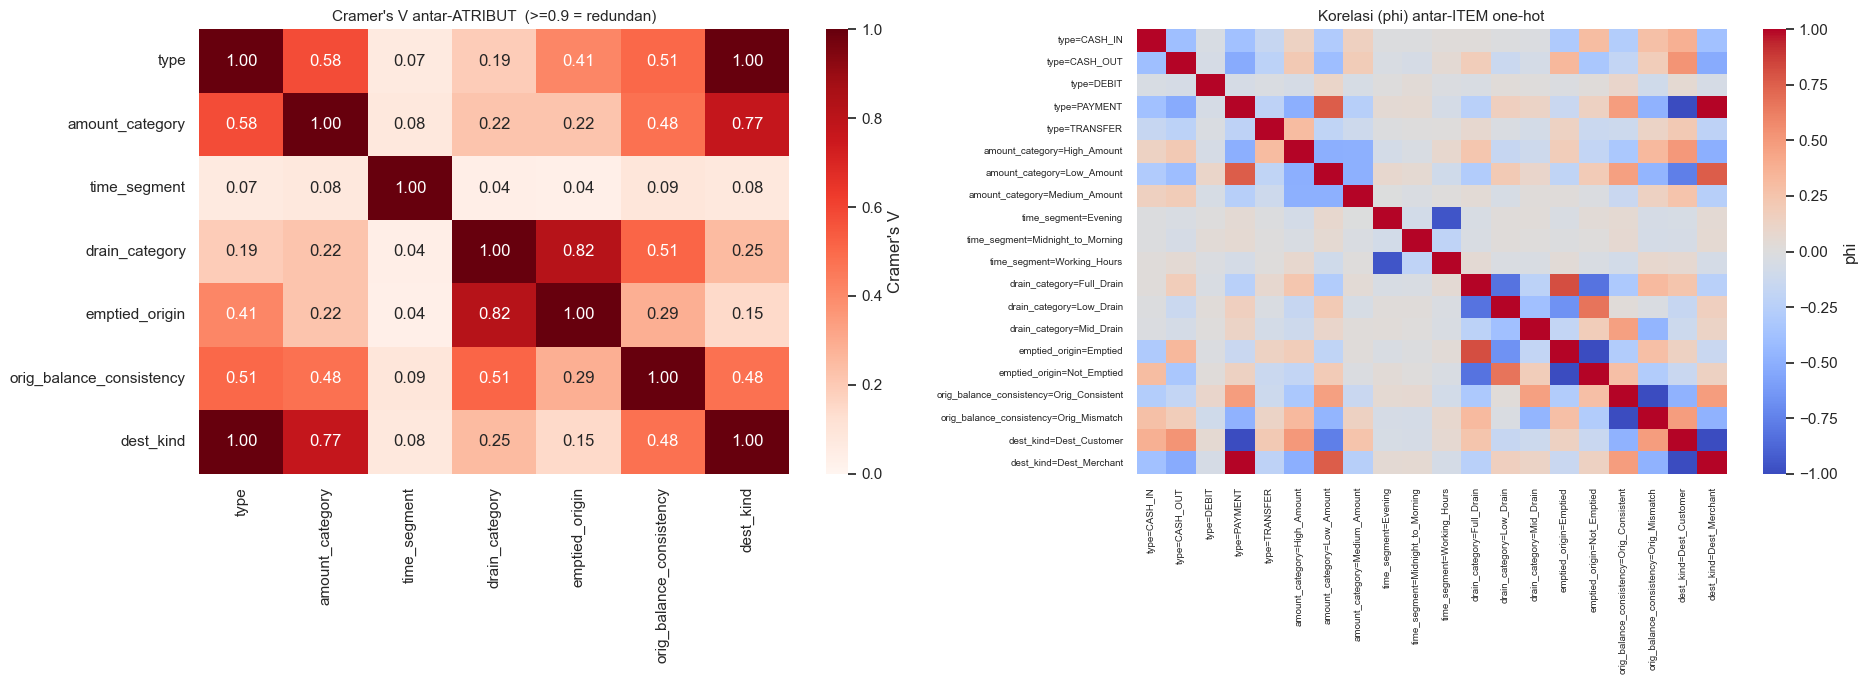

Pasangan ATRIBUT paling redundan (Cramer's V):
  1.000  type <-> dest_kind   <== REDUNDAN TINGGI
  0.817  drain_category <-> emptied_origin
  0.773  amount_category <-> dest_kind
  0.578  type <-> amount_category
  0.513  drain_category <-> orig_balance_consistency

Pasangan ITEM antar-atribut paling berkorelasi -> kandidat rule TAUTOLOGIS:
  phi=+1.00  type=PAYMENT <-> dest_kind=Dest_Merchant
  phi=-1.00  type=PAYMENT <-> dest_kind=Dest_Customer
  phi=-0.82  drain_category=Full_Drain <-> emptied_origin=Not_Emptied
  phi=+0.82  drain_category=Full_Drain <-> emptied_origin=Emptied
  phi=+0.76  type=PAYMENT <-> amount_category=Low_Amount
  phi=+0.76  amount_category=Low_Amount <-> dest_kind=Dest_Merchant

Pasangan atribut untuk difilter (Cramer's V >= 0.9): [('type', 'dest_kind')]


In [33]:
# Cek redundansi pada sampel 1 jt (rasio kategorikal bersifat sample-invariant -> stabil & cepat).
from scipy.stats import chi2_contingency

_s = np.random.RandomState(42).choice(len(df), 1_000_000, replace=False)
_df = df.iloc[_s]
_bk = basket.iloc[_s].astype(int)

def cramers_v(a, b):
    cm = pd.crosstab(a, b).values
    chi2 = chi2_contingency(cm)[0]
    n = cm.sum(); r, k = cm.shape
    return np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1))

cols = list(_df.columns)
cv = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        cv.iloc[i, j] = cv.iloc[j, i] = cramers_v(_df[cols[i]], _df[cols[j]])

phi = _bk.corr()   # phi = korelasi Pearson pada item biner 0/1

fig, ax = plt.subplots(1, 2, figsize=(19, 7))
sns.heatmap(cv, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1, ax=ax[0],
            cbar_kws={'label': "Cramer's V"})
ax[0].set_title("Cramer's V antar-ATRIBUT  (>=0.9 = redundan)", fontsize=11)
sns.heatmap(phi, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax[1],
            cbar_kws={'label': 'phi'}, xticklabels=True, yticklabels=True)
ax[1].set_title('Korelasi (phi) antar-ITEM one-hot', fontsize=11)
ax[1].tick_params(labelsize=7)
plt.tight_layout(); plt.show()

pairs = sorted([(cv.iloc[i, j], cols[i], cols[j])
                for i in range(len(cols)) for j in range(i + 1, len(cols))], reverse=True)
print("Pasangan ATRIBUT paling redundan (Cramer's V):")
for v, a, b in pairs[:5]:
    print(f"  {v:.3f}  {a} <-> {b}" + ('   <== REDUNDAN TINGGI' if v >= 0.9 else ''))

# Pasangan ITEM one-hot -- hanya ANTAR-atribut (komplemen dalam-atribut spt Emptied<->Not_Emptied
# selalu -1 dan tidak informatif, jadi dikecualikan).
it = list(phi.columns)
attr = lambda s: s.split('=')[0]
ip = sorted([(abs(phi.iloc[i, j]), phi.iloc[i, j], it[i], it[j])
             for i in range(len(it)) for j in range(i + 1, len(it))
             if attr(it[i]) != attr(it[j])], reverse=True)
print('\nPasangan ITEM antar-atribut paling berkorelasi -> kandidat rule TAUTOLOGIS:')
for _, r, a, b in ip[:6]:
    print(f"  phi={r:+.2f}  {a} <-> {b}")

# Simpan pasangan atribut redundan tinggi -> dipakai untuk filter anti-tautologi di Section 6
REDUNDANT_ATTR_PAIRS = [(a, b) for v, a, b in pairs if v >= 0.9]
print('\nPasangan atribut untuk difilter (Cramer\'s V >= 0.9):', REDUNDANT_ATTR_PAIRS)

**Interpretasi hasil (data nyata):**

- **`type ↔ dest_kind` (Cramér's V ≈ 1,0):** `dest_kind` **redundan sempurna** dengan `type` — di PaySim hanya PAYMENT yang ke merchant. Setiap rule yang memasangkan keduanya (mis. `type=PAYMENT ↔ dest_kind=Dest_Merchant`) bersifat **tautologis**.
- **`emptied_origin ⊂ drain_category` (V ≈ 0,82):** `Emptied` **selalu** `Full_Drain` (P(Full_Drain | Emptied) = 100%). Rule `Emptied ↔ Full_Drain` semi-tautologis.
- **`drain_category ↔ orig_balance_consistency` (V ≈ 0,5):** cukup tinggi — inilah sumber rule `... → orig_balance_consistency=Orig_Consistent` ber-confidence 1,0 yang memenuhi top-12 saat ini.

## 4. Frequent itemset mining with Apriori

**`min_support = 0.01`** — sebuah itemset harus muncul pada minimal 1% (≈ 64 ribu) transaksi. Cukup rendah untuk menjaga interaksi `DEBIT` (0,65%) tetap terlihat, tapi cukup tinggi untuk memangkas noise.

**Dua parameter skala (wajib pada 6,3 juta baris × 20 item):**

| Parameter | Alasan |
|---|---|
| `low_memory=True` | Mode default mlxtend menguji **semua kombinasi kandidat sekaligus** → mencoba mengalokasikan array `(6.362.620 × 576)` bool = **3,4 GiB** → `MemoryError`. Mode ini memproses kombinasi **satu per satu**: hemat RAM, sedikit lebih lambat (~21 detik). |
| `max_len=4` | Membatasi itemset maksimal 4 item → rule maksimal **3 antecedent + 1 consequent**. Tetap dapat diinterpretasikan audiens bisnis, sekaligus memangkas ruang kombinasi secara eksponensial. |

> **Catatan:** dengan 3 atribut lama basket hanya 11 item sehingga mode default masih muat. Setelah hand-off diperkaya menjadi 7 atribut (20 item), kedua parameter ini menjadi keharusan — notebook pendamping (`PA_anomaly_pattern_mining_and_validation`) memang sudah memakainya sejak awal.

In [34]:
MIN_SUPPORT = 0.01

# low_memory=True  -> WAJIB pada skala ini.
#   Mode default mlxtend memvalidasi SEMUA kombinasi kandidat sekaligus, yaitu
#   mengalokasikan array (6.362.620 x 576) bool = 3,4 GiB -> MemoryError.
#   low_memory memproses kombinasi satu per satu (sedikit lebih lambat, hemat RAM).
# max_len=4        -> batasi panjang itemset menjadi maksimal 4 item.
#   Konsekuensinya rule maksimal 3 antecedent + 1 consequent: tetap interpretable
#   untuk audiens bisnis, sekaligus memangkas ruang kombinasi secara drastis.
frequent_itemsets = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True,
                            max_len=4, low_memory=True)

frequent_itemsets['n_items'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values(['n_items', 'support'], ascending=[True, False])
print(f'{len(frequent_itemsets)} frequent itemsets at min_support={MIN_SUPPORT}')
print('Itemset sizes:', frequent_itemsets['n_items'].value_counts().sort_index().to_dict())
frequent_itemsets.head(15)

1060 frequent itemsets at min_support=0.01
Itemset sizes: {1: 19, 2: 127, 3: 368, 4: 546}


,support,itemsets,n_items
16,0.785963,frozenset({orig_balance_consistency=Orig_Misma...,1
14,0.761013,frozenset({emptied_origin=Not_Emptied}),1
9,0.701195,frozenset({time_segment=Working_Hours}),1
17,0.661854,frozenset({dest_kind=Dest_Customer}),1
11,0.585068,frozenset({drain_category=Low_Drain}),1
1,0.351663,frozenset({type=CASH_OUT}),1
2,0.338146,frozenset({type=PAYMENT}),1
18,0.338146,frozenset({dest_kind=Dest_Merchant}),1
5,0.333333,frozenset({amount_category=Low_Amount}),1
4,0.333333,frozenset({amount_category=High_Amount}),1


## 5. Generate association rules
From the frequent itemsets we derive rules and compute the three interestingness measures:

- **Support** — how often antecedent + consequent occur together (coverage).
- **Confidence** — P(consequent | antecedent): reliability of the rule.
- **Lift** — confidence ÷ baseline support of the consequent. **Lift > 1** = positive association; the higher, the more surprising.

In [35]:
try:
    rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
except TypeError:
    # mlxtend >=0.25 may require num_itemsets for some metrics
    rules = association_rules(frequent_itemsets, num_itemsets=len(frequent_itemsets),
                              metric='lift', min_threshold=1.0)

def fmt(s):
    return ', '.join(sorted(s))
rules['antecedent'] = rules['antecedents'].apply(fmt)
rules['consequent'] = rules['consequents'].apply(fmt)
print(f'{len(rules)} candidate rules generated (lift >= 1.0).')
rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(12)

7242 candidate rules generated (lift >= 1.0).


,antecedent,consequent,support,confidence,lift
5863,"dest_kind=Dest_Customer, orig_balance_consiste...","drain_category=Mid_Drain, type=CASH_OUT",0.024703,0.504722,20.431585
5860,"drain_category=Mid_Drain, type=CASH_OUT","dest_kind=Dest_Customer, orig_balance_consiste...",0.024703,0.999994,20.431585
4203,"drain_category=Full_Drain, type=PAYMENT","dest_kind=Dest_Merchant, emptied_origin=Emptied",0.051375,0.941521,18.326469
4200,"dest_kind=Dest_Merchant, emptied_origin=Emptied","drain_category=Full_Drain, type=PAYMENT",0.051375,1.000000,18.326469
4201,"dest_kind=Dest_Merchant, drain_category=Full_D...","emptied_origin=Emptied, type=PAYMENT",0.051375,0.941521,18.326469
4202,"emptied_origin=Emptied, type=PAYMENT","dest_kind=Dest_Merchant, drain_category=Full_D...",0.051375,1.000000,18.326469
5130,"amount_category=Low_Amount, emptied_origin=Emp...","drain_category=Full_Drain, type=PAYMENT",0.034794,0.877615,16.083582
5156,"amount_category=Low_Amount, emptied_origin=Emp...","dest_kind=Dest_Merchant, drain_category=Full_D...",0.034794,0.877615,16.083582
5155,"dest_kind=Dest_Merchant, drain_category=Full_D...","amount_category=Low_Amount, emptied_origin=Emp...",0.034794,0.637651,16.083582
5133,"drain_category=Full_Drain, type=PAYMENT","amount_category=Low_Amount, emptied_origin=Emp...",0.034794,0.637651,16.083582


## 6. Filter for non-trivial, high-lift rules
Kita hanya menyimpan rule yang **andal dan mengejutkan**, lalu membuang yang trivial/redundan:

**Ambang statistik:**
- `lift > 1.2` — bermakna di atas kebetulan.
- `confidence > 0.5` — berlaku untuk mayoritas transaksi yang cocok.
- `support > 0.01` — mencakup porsi data yang tidak sepele.
- **consequent tunggal** — tiap rule punya satu kesimpulan jelas.

**Filter anti-tautologi (baru, memakai hasil Redundancy Check 3b):**
- Buang rule yang memasangkan **atribut redundan by-construction** — `{type, dest_kind}` (Cramér's V = 1,0) dan `{drain_category, emptied_origin}` (V = 0,82). Rule seperti `type=PAYMENT → dest_kind=Dest_Merchant` **tautologis** (lift tinggi, nol insight).
- Buang rule ber-consequent `dest_kind=...` karena `dest_kind` ekuivalen `type` → hanya menduplikasi rule `→ type`.

> Tanpa filter ini, top-rules didominasi tautologi (mis. semua `→ Orig_Consistent` confidence 1,0) dan **melanggar syarat "non-trivial"** rubrik.

In [36]:
# ── Filter anti-tautologi (memakai temuan Redundancy Check 3b) ────────────────
# Pasangan atribut yang redundan BY CONSTRUCTION -> rule yang memasangkannya tautologis:
#   {type, dest_kind}                : Cramer's V = 1.00  (dest_kind fungsi deterministik type)
#   {drain_category, emptied_origin} : Cramer's V = 0.82  (Emptied SELALU Full_Drain)
TAUTO_PAIRS = [{'type', 'dest_kind'}, {'drain_category', 'emptied_origin'}]

def _rule_attrs(row):
    items = list(row['antecedents']) + list(row['consequents'])
    return {it.split('=')[0] for it in items}

def _is_tautological(row):
    attrs = _rule_attrs(row)
    # (a) rule menyentuh KEDUA anggota pasangan redundan -> tautologis
    if any(pair <= attrs for pair in TAUTO_PAIRS):
        return True
    # (b) consequent = dest_kind (ekuivalen type) -> hanya duplikat rule "-> type", buang
    if row['consequent'].startswith('dest_kind='):
        return True
    return False

_base = ((rules['lift'] > 1.2) &             # asosiasi jelas di atas kebetulan
         (rules['confidence'] > 0.5) &        # berlaku untuk mayoritas kasus
         (rules['support'] > 0.01) &          # mencakup porsi data yang berarti
         (rules['consequents'].apply(len) == 1))  # satu kesimpulan yang jelas
strong = rules[_base & (~rules.apply(_is_tautological, axis=1))].copy()
strong = strong.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'{int(_base.sum())} rule lolos ambang statistik; '
      f'{int(_base.sum()) - len(strong)} tautologis dibuang -> {len(strong)} strong rules.')
strong[['antecedent', 'consequent', 'support', 'confidence', 'lift']].round(3)

1294 rule lolos ambang statistik; 817 tautologis dibuang -> 477 strong rules.


,antecedent,consequent,support,confidence,lift
0,"amount_category=Medium_Amount, orig_balance_co...",drain_category=Mid_Drain,0.015,0.668,7.035
1,"amount_category=Medium_Amount, dest_kind=Dest_...",drain_category=Mid_Drain,0.016,0.664,6.988
2,"orig_balance_consistency=Orig_Consistent, time...",drain_category=Mid_Drain,0.017,0.619,6.521
3,"orig_balance_consistency=Orig_Consistent, type...",drain_category=Mid_Drain,0.025,0.613,6.457
4,"amount_category=Medium_Amount, orig_balance_co...",drain_category=Mid_Drain,0.026,0.593,6.247
...,...,...,...,...,...
472,"dest_kind=Dest_Customer, drain_category=Low_Dr...",orig_balance_consistency=Orig_Mismatch,0.091,0.945,1.203
473,"dest_kind=Dest_Merchant, orig_balance_consiste...",drain_category=Low_Drain,0.122,0.703,1.202
474,"orig_balance_consistency=Orig_Mismatch, type=P...",drain_category=Low_Drain,0.122,0.703,1.202
475,"dest_kind=Dest_Merchant, time_segment=Working_...",drain_category=Low_Drain,0.157,0.703,1.201


## 7. Visualize the rule space

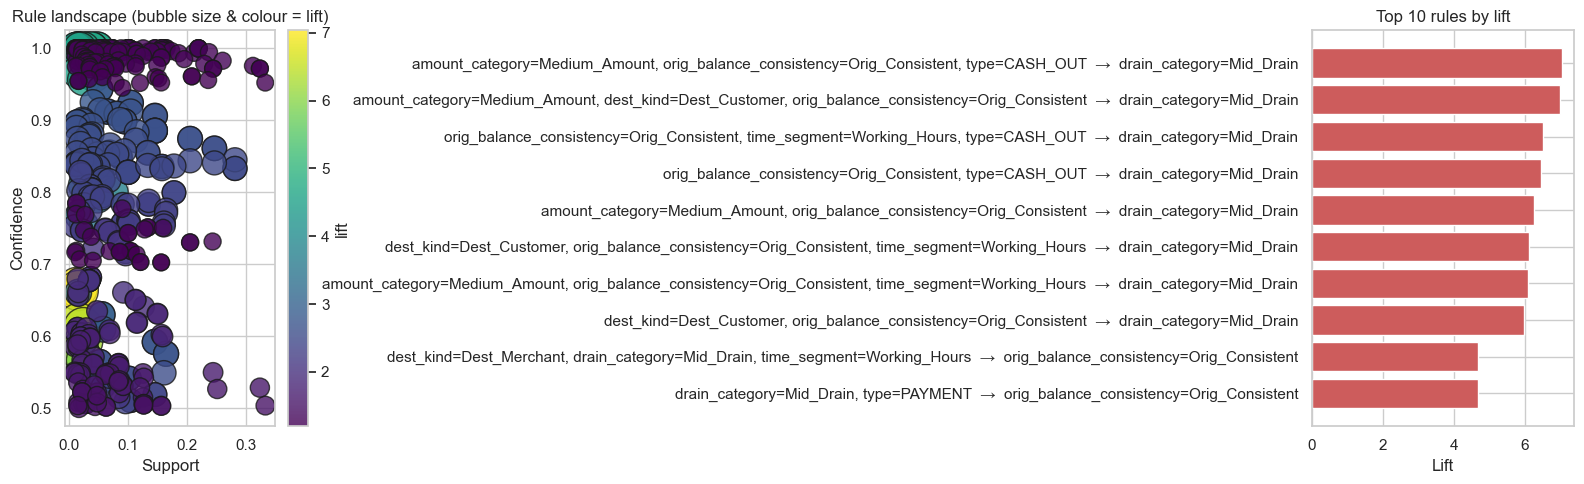

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) support vs confidence, sized/coloured by lift
sc = axes[0].scatter(strong['support'], strong['confidence'],
                     s=strong['lift'] * 120, c=strong['lift'],
                     cmap='viridis', alpha=0.8, edgecolor='k')
axes[0].set_xlabel('Support'); axes[0].set_ylabel('Confidence')
axes[0].set_title('Rule landscape (bubble size & colour = lift)')
fig.colorbar(sc, ax=axes[0], label='lift')

# (b) top 10 rules by lift
top = strong.head(10).iloc[::-1]
labels = (top['antecedent'] + '  →  ' + top['consequent'])
axes[1].barh(labels, top['lift'], color='indianred')
axes[1].set_xlabel('Lift'); axes[1].set_title('Top 10 rules by lift')
plt.tight_layout(); plt.show()

## 8. Deliverable — documented rules with business interpretation
The table below takes the strongest rules and attaches a plain-language reading. Interpretations are generated from the rule's own metrics so they stay accurate if the data is re-run.

In [38]:
# De-duplicate symmetric pairs (A->B and B->A share the same lift) so the
# documented list shows distinct relationships, keeping the higher-confidence direction.
strong['pair_key'] = strong.apply(
    lambda r: frozenset(r['antecedents'] | r['consequents']), axis=1)

# Diversity cap: maksimal 2 rule per consequent -> deliverable BERAGAM, tidak didominasi
# satu kesimpulan (mis. semua "-> Orig_Consistent"). Memenuhi semangat rubrik "non-trivial".
documented = (strong.sort_values('confidence', ascending=False)
                    .drop_duplicates('pair_key')
                    .groupby('consequent', group_keys=False).head(2)
                    .sort_values('lift', ascending=False)
                    .head(12)
                    .reset_index(drop=True))

def interpret(row):
    a, c = row['antecedent'], row['consequent']
    return (f"When a transaction is [{a}], it is [{c}] "
            f"{row['confidence']*100:.0f}% of the time - "
            f"{row['lift']:.1f}x more often than the {c} baseline.")

documented['business_interpretation'] = documented.apply(interpret, axis=1)
documented.index = documented.index + 1
documented.index.name = 'rule_#'
out = documented[['antecedent', 'consequent', 'support', 'confidence', 'lift', 'business_interpretation']].round(3)
print('Sebaran consequent (harus beragam):', documented['consequent'].value_counts().to_dict())
out

Sebaran consequent (harus beragam): {'orig_balance_consistency=Orig_Consistent': 2, 'amount_category=Low_Amount': 2, 'amount_category=High_Amount': 2, 'type=PAYMENT': 2, 'type=CASH_OUT': 2, 'drain_category=Mid_Drain': 1, 'amount_category=Medium_Amount': 1}


,antecedent,consequent,support,confidence,lift,business_interpretation
rule_#,,,,,,
1,"amount_category=Medium_Amount, dest_kind=Dest_...",drain_category=Mid_Drain,0.016,0.664,6.988,When a transaction is [amount_category=Medium_...
2,"drain_category=Mid_Drain, type=PAYMENT",orig_balance_consistency=Orig_Consistent,0.048,1.000,4.672,When a transaction is [drain_category=Mid_Drai...
3,"dest_kind=Dest_Merchant, drain_category=Mid_Dr...",orig_balance_consistency=Orig_Consistent,0.030,1.000,4.672,When a transaction is [dest_kind=Dest_Merchant...
4,"orig_balance_consistency=Orig_Consistent, time...",amount_category=Low_Amount,0.053,0.944,2.831,When a transaction is [orig_balance_consistenc...
5,"dest_kind=Dest_Merchant, orig_balance_consiste...",amount_category=Low_Amount,0.053,0.944,2.831,When a transaction is [dest_kind=Dest_Merchant...
6,"emptied_origin=Emptied, time_segment=Working_H...",amount_category=High_Amount,0.024,0.901,2.703,"When a transaction is [emptied_origin=Emptied,..."
7,"drain_category=Full_Drain, time_segment=Workin...",amount_category=High_Amount,0.024,0.899,2.697,When a transaction is [drain_category=Full_Dra...
8,"amount_category=Low_Amount, orig_balance_consi...",type=PAYMENT,0.146,0.906,2.679,When a transaction is [amount_category=Low_Amo...
9,"amount_category=Low_Amount, orig_balance_consi...",type=PAYMENT,0.087,0.901,2.664,When a transaction is [amount_category=Low_Amo...


In [39]:
# Export the deliverable for the final report / dashboard (Phase 5)
# Path EKSPLISIT ke real_used agar konsisten dengan hand-off lain (bukan tergantung cwd).
export_dir = DATA_PATH.parent
export_path = export_dir / 'phase3_association_rules.csv'
out.to_csv(export_path)
print(f'Saved {len(out)} documented rules -> {export_path.resolve()}')

Saved 12 documented rules -> D:\PPTI\Cawu 5\Data Mining\Lecturer\PhySim_Synthetic_Financial_Fraud\data\processed\real_used\phase3_association_rules.csv


### Business interpretation (banking context)
Kenapa rule ini **non-trivial**: hitungan frekuensi satu-kolom hanya bilang "33% transaksi High_Amount" — tapi **tidak** mengungkap bahwa band nominal ditentukan oleh **channel + perilaku saldo**. Rule mengaitkan atribut yang secara tabulasi biasa tampak lepas. *(Angka mengikuti tabel yang tercetak; re-run untuk memverifikasi.)*

| Tema | Contoh rule | Maknanya | Relevansi fraud / Phase 4 |
|---|---|---|---|
| **TRANSFER yang menguras saldo = nominal besar** ⚠️ | `TRANSFER + Full_Drain/Emptied + Working_Hours → High_Amount` (conf ~0,90, lift ~2,70) | Transfer yang mengosongkan rekening hampir pasti bernilai besar. | **Sinyal paling relevan fraud** — pola *layering* (menguras lalu memindahkan dana besar). Prioritas pengawasan Phase 4. |
| **Pengosongan rekening = CASH_OUT** ⚠️ | `Emptied + Medium_Amount (+Evening) → CASH_OUT` (conf 0,75–0,83, lift ~2,1–2,4) | Rekening yang dikosongkan cenderung lewat penarikan tunai. | Kaki kedua pola *cash-out* — layak di-cross-reference dengan anomali Phase 4. |
| **Transaksi kecil = PAYMENT ritel** | `Low_Amount + Orig_Consistent → PAYMENT` (conf ~0,91, lift ~2,68); `Evening + PAYMENT → Low_Amount` (lift ~2,83) | Nilai kecil = belanja konsumtif rutin dengan saldo yang cocok. | Baseline "normal" — PAYMENT kecil = risiko rendah. |
| **Pengurasan sebagian = saldo konsisten** | `Mid_Drain + type/waktu → Orig_Consistent` (conf 1,0, lift 4,67) | Pengurasan parsial selalu punya saldo yang balance secara logika. | Menandai transaksi "rapi/wajar" — bukan indikator risiko. |

**Takeaway satu kalimat:** *Di PaySim, band nominal ditentukan channel + perilaku pengurasan saldo; kombinasi **TRANSFER/CASH_OUT yang mengosongkan rekening + nominal besar** adalah pola paling dekat dengan fraud — di sanalah pengawasan Phase 4 harus terkonsentrasi.*

## 9. Findings & answer to the discovery question
*What did we discover that was not already obvious from the raw data?*

**Baca tabel rule yang tercetak untuk angka pastinya.** Pola dominan yang stabil (setelah filter anti-tautologi):

1. **Perilaku pengurasan saldo mengikat channel & nominal.** Kombinasi seperti `TRANSFER + Full_Drain/Emptied + Working_Hours → High_Amount` (lift ~2,7) menunjukkan bahwa **transfer yang mengosongkan rekening hampir pasti bernilai besar** — hubungan yang tak terlihat dari menghitung tipe atau nominal secara terpisah.
2. **Dua kaki pola pemindahan dana:** `Emptied → CASH_OUT` melengkapi `Emptied → TRANSFER besar` — konsisten dengan skenario *menguras lalu mencairkan*.
3. **Transaksi kecil = PAYMENT ritel dengan saldo konsisten** (lift ~2,7) menjadi baseline "normal" yang bersih.
4. **Redundansi terukur & ditangani:** `dest_kind` redundan sempurna dengan `type` (Cramér's V = 1,0) dan `emptied_origin ⊂ drain_category` — rule tautologisnya sudah **disaring** (Section 6) agar deliverable tetap non-trivial.

### Why this matters for fraud (banking context)
Fraud PaySim **hanya** lewat `TRANSFER` dan `CASH_OUT` bernilai besar. Rule top kami secara mandiri menyoroti **TRANSFER/CASH_OUT yang menguras/mengosongkan rekening + nominal besar** — persis populasi yang harus difokuskan Phase 4. Transaksi yang **melanggar** pola dominan (mis. TRANSFER ber-nominal kecil, atau rekening dikosongkan di luar pola normal) adalah kandidat anomali.

### Compliance note & companion analysis
Sesuai Dataset Reference Document, `isFraud` **tidak** dipakai sebagai target mining — hanya validasi post-mining. **Notebook ini 100% label-free.** Notebook pendamping `PA_anomaly_pattern_mining_and_validation.ipynb` menambang pola **langka** dari hand-off yang sama, lalu memvalidasinya terhadap `isFraud` **setelah** mining — menghasilkan `phase3_rule_based_anomaly_flags.parquet` untuk Phase 4.